In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

- Dataset: https://www.kaggle.com/datasets/kaushalnandania/student-placement-dataset/data

In [ ]:
path = r"/kaggle/input/student-placement-dataset/0000.parquet"

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Intro

In [122]:
df = pd.read_parquet(path)

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2966 entries, 0 to 2965
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Internships        2966 non-null   int64
 1   CGPA               2966 non-null   int64
 2   HistoryOfBacklogs  2966 non-null   int64
 3   PlacedOrNot        2966 non-null   int64
dtypes: int64(4)
memory usage: 92.8 KB


In [124]:
df.head(3)

,Internships,CGPA,HistoryOfBacklogs,PlacedOrNot
0,1,8,1,1
1,0,7,1,1
2,1,6,0,1


In [125]:
# first for most -> dataset is balanced
df['PlacedOrNot'].value_counts()

PlacedOrNot
1    1639
0    1327
Name: count, dtype: int64

In [126]:
# data based on cgpa
df.groupby('CGPA').sum()

,Internships,HistoryOfBacklogs,PlacedOrNot
CGPA,,,
5,59,17,7
6,576,161,270
7,679,186,282
8,648,172,915
9,125,34,165


# EDA

In [127]:
def plot_pie(col):
    df[col].value_counts().plot.pie(autopct='%1.1f%%')
    plt.title(f"{col} Count Distribution")
    plt.show()

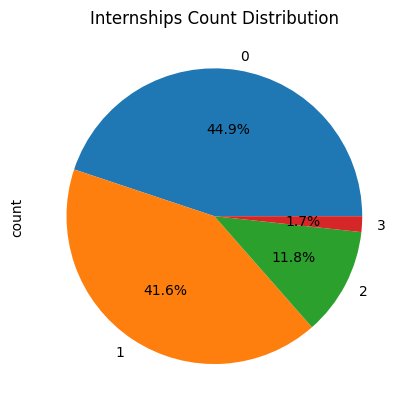

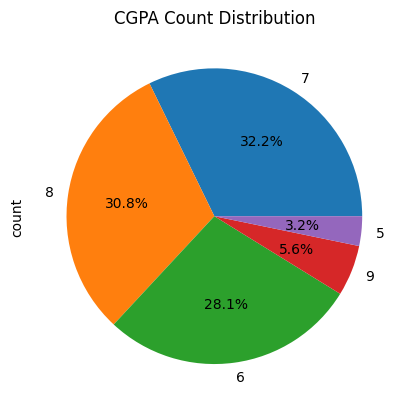

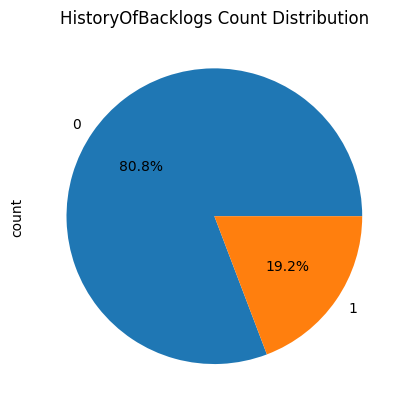

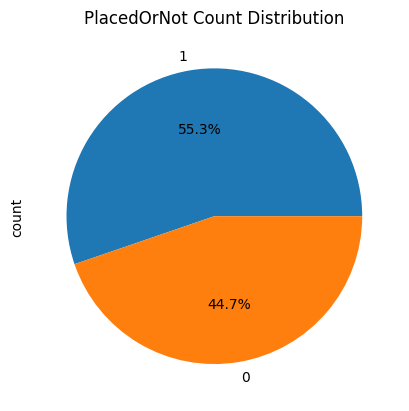

In [128]:
for col in df.columns:
    plot_pie(col)

In [129]:
# No of students who placed with backlog

df[df['HistoryOfBacklogs'] == 1] \
    .groupby('PlacedOrNot') \
    [['Internships', 'PlacedOrNot']].sum()

,Internships,PlacedOrNot
PlacedOrNot,,
0,166,0
1,222,302


In [130]:
df[(df['HistoryOfBacklogs'] == 1) & (df['PlacedOrNot'] == 1)]

,Internships,CGPA,HistoryOfBacklogs,PlacedOrNot
0,1,8,1,1
1,0,7,1,1
3,0,8,1,1
11,1,8,1,1
13,1,8,1,1
...,...,...,...,...
2886,0,8,1,1
2893,0,8,1,1
2904,2,8,1,1
2947,2,8,1,1


# Model Building

In [131]:
X = df.drop(columns='PlacedOrNot')
y = df['PlacedOrNot']

In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [133]:
print(f"{X_train.shape}, {X_test.shape}")
print(f"{y_train.shape}, {y_test.shape}")

(2372, 3), (594, 3)
(2372,), (594,)


In [134]:
# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [135]:
X_test_scaled

array([[-0.94255024, -0.09835162,  2.10131509],
       [ 1.77731492,  0.94312179,  2.10131509],
       [ 0.41738234,  0.94312179, -0.47589246],
       ...,
       [-0.94255024, -0.09835162,  2.10131509],
       [ 1.77731492, -0.09835162, -0.47589246],
       [ 0.41738234, -0.09835162,  2.10131509]])

# Logistic Regression

In [136]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [137]:
y_pred_log = log_model.predict(X_test_scaled)

In [138]:
accuracy_score(y_test, y_pred_log)

0.734006734006734

In [139]:
print(confusion_matrix(y_test, y_pred_log))

[[201  79]
 [ 79 235]]


In [140]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72       280
           1       0.75      0.75      0.75       314

    accuracy                           0.73       594
   macro avg       0.73      0.73      0.73       594
weighted avg       0.73      0.73      0.73       594



In [141]:
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]
print(roc_auc_score(y_test, y_prob))

0.8312101910828025


# Random Forest

In [142]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [143]:
y_pred_rf = rf_model.predict(X_test)

In [144]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8417508417508418
[[269  11]
 [ 83 231]]
              precision    recall  f1-score   support

           0       0.76      0.96      0.85       280
           1       0.95      0.74      0.83       314

    accuracy                           0.84       594
   macro avg       0.86      0.85      0.84       594
weighted avg       0.86      0.84      0.84       594



In [145]:
importances = rf_model.feature_importances_

for feature, importance in zip(X.columns, importances):
    print(feature, ":", importance)

Internships : 0.10349434036219322
CGPA : 0.8871758745963383
HistoryOfBacklogs : 0.009329785041468482
